 Food Quality Analysis System — Healthy vs Rotten

# Import Libraries

In [ ]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
 
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
 
import cv2
from pathlib import Path
 
# Confirm GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2026-05-03 07:05:04.559610: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777791904.780739      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777791904.859471      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777791905.396782      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777791905.396822      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777791905.396825      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# Configuration (All hyperparameters in one place)

In [2]:
class CFG:
    DATASET_PATH = (
        "/kaggle/input/datasets/muhammad0subhan/"
        "fruit-and-vegetable-disease-healthy-vs-rotten/"
        "Fruit And Vegetable Diseases Dataset"
    )
    IMG_SIZE     = (224, 224)
    BATCH_SIZE   = 32
    EPOCHS       = 30
    LR           = 1e-4
    NUM_CLASSES  = 28
    SEED         = 42
    MODEL_PATH   = "food_quality_Fruits.h5"
 
    # Data split ratios
    TRAIN_RATIO  = 0.70
    VAL_RATIO    = 0.10
    TEST_RATIO   = 0.20

# Build File Paths DataFrame
# Walk the dataset directory, collect image paths + labels

In [3]:
def build_dataframe(dataset_path: str) -> pd.DataFrame:
    records = []
    base = Path(dataset_path)
 
    for class_dir in sorted(base.iterdir()):
        if not class_dir.is_dir():
            continue
        label = class_dir.name
        for img_file in class_dir.glob("*"):
            if img_file.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}:
                records.append({"filepath": str(img_file), "label": label})
 
    df = pd.DataFrame(records)
    print(f"Total images found : {len(df)}")
    print(f"Total classes found: {df['label'].nunique()}")
    print("______________________________")
    print(df['label'].value_counts().to_string())
    return df
 
 
df = build_dataframe(CFG.DATASET_PATH)

Total images found : 29277
Total classes found: 28
______________________________
label
Apple__Rotten           2925
Banana__Rotten          2797
Apple__Healthy          2438
Mango__Rotten           2247
Orange__Rotten          2186
Orange__Healthy         2075
Banana__Healthy         1999
Mango__Healthy          1813
Strawberry__Healthy     1603
Strawberry__Rotten      1596
Carrot__Healthy          619
Potato__Healthy          614
Bellpepper__Healthy      611
Cucumber__Healthy        608
Tomato__Healthy          604
Tomato__Rotten           595
Cucumber__Rotten         593
Bellpepper__Rotten       591
Potato__Rotten           584
Carrot__Rotten           579
Grape__Rotten            200
Grape__Healthy           200
Jujube__Healthy          200
Jujube__Rotten           200
Guava__Healthy           200
Guava__Rotten            200
Pomegranate__Healthy     200
Pomegranate__Rotten      200


# Split Dataset: Train / Validation / Test


In [4]:
def split_dataset(df: pd.DataFrame):

    # First split: 80% train+val  |  20% test
    train_val_df, test_df = train_test_split(
        df,
        test_size=CFG.TEST_RATIO,
        stratify=df["label"],
        random_state=CFG.SEED
    )
    # Second split: 87.5% train  |  12.5% val  → gives 70/10 of total
    val_ratio_adjusted = CFG.VAL_RATIO / (CFG.TRAIN_RATIO + CFG.VAL_RATIO)
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=val_ratio_adjusted,
        stratify=train_val_df["label"],
        random_state=CFG.SEED
    )
 
    print(f"\n📊 Dataset Split:")
    print(f"   Train      : {len(train_df):>6} images ({len(train_df)/len(df)*100:.1f}%)")
    print(f"   Validation : {len(val_df):>6} images ({len(val_df)/len(df)*100:.1f}%)")
    print(f"   Test       : {len(test_df):>6} images ({len(test_df)/len(df)*100:.1f}%)")
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)
 
 
train_df, val_df, test_df = split_dataset(df)


📊 Dataset Split:
   Train      :  20493 images (70.0%)
   Validation :   2928 images (10.0%)
   Test       :   5856 images (20.0%)


# Data Generators (Preprocessing + Augmentation)

In [ ]:
def build_generators(train_df, val_df, test_df):
    # Augmentation for training only
    train_datagen = ImageDataGenerator(
        rescale=1.0 / 255.0,          # Normalize [0, 1]
        rotation_range=20,            # Rotate up to 20°
        horizontal_flip=True,         # Random horizontal flip
        vertical_flip=False,          # Food images don't need vertical flip
        zoom_range=0.15,              # Zoom in/out by 15%
        width_shift_range=0.1,        # Shift horizontally
        height_shift_range=0.1,       # Shift vertically
        brightness_range=[0.8, 1.2],  # Mimic lighting variation
        fill_mode="nearest"
    )
 
    # No augmentation for val / test — just normalize
    eval_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
 
    common_kwargs = dict(
        x_col="filepath",
        y_col="label",
        target_size=CFG.IMG_SIZE,
        batch_size=CFG.BATCH_SIZE,
        class_mode="categorical",
        seed=CFG.SEED
    )
 
    train_gen = train_datagen.flow_from_dataframe(train_df, shuffle=True,  **common_kwargs)
    val_gen   = eval_datagen.flow_from_dataframe(val_df,   shuffle=False, **common_kwargs)
    test_gen  = eval_datagen.flow_from_dataframe(test_df,  shuffle=False, **common_kwargs)
 
    return train_gen, val_gen, test_gen
 
 
train_gen, val_gen, test_gen = build_generators(train_df, val_df, test_df)
 
# Save class mapping for later use (prediction)
CLASS_NAMES  = list(train_gen.class_indices.keys())
CLASS_INDICES = train_gen.class_indices
print(f"\nClasses ({len(CLASS_NAMES)}): {CLASS_NAMES}")
 

Found 20493 validated image filenames belonging to 28 classes.
Found 2928 validated image filenames belonging to 28 classes.
Found 5856 validated image filenames belonging to 28 classes.

✅ Classes (28): ['Apple__Healthy', 'Apple__Rotten', 'Banana__Healthy', 'Banana__Rotten', 'Bellpepper__Healthy', 'Bellpepper__Rotten', 'Carrot__Healthy', 'Carrot__Rotten', 'Cucumber__Healthy', 'Cucumber__Rotten', 'Grape__Healthy', 'Grape__Rotten', 'Guava__Healthy', 'Guava__Rotten', 'Jujube__Healthy', 'Jujube__Rotten', 'Mango__Healthy', 'Mango__Rotten', 'Orange__Healthy', 'Orange__Rotten', 'Pomegranate__Healthy', 'Pomegranate__Rotten', 'Potato__Healthy', 'Potato__Rotten', 'Strawberry__Healthy', 'Strawberry__Rotten', 'Tomato__Healthy', 'Tomato__Rotten']


# Visualise Sample Images


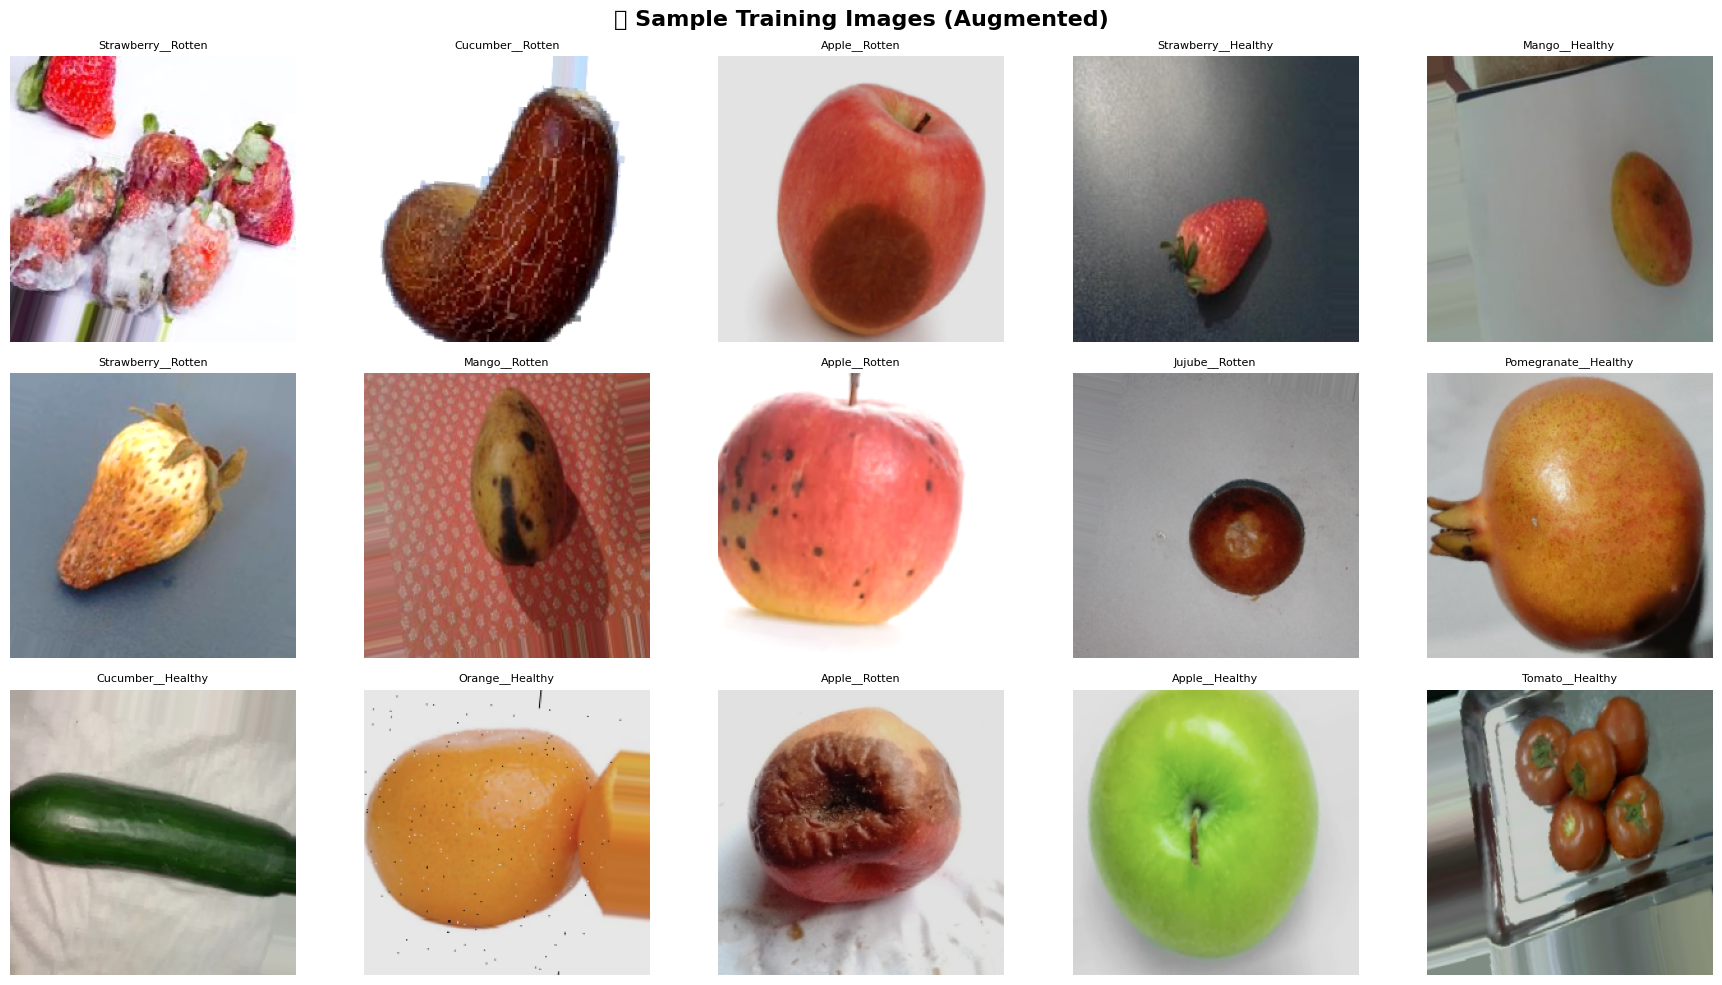

In [6]:
def show_samples(generator, n_cols=5, n_rows=3):
    """Display a grid of sample training images with labels."""
    images, labels = next(generator)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
    fig.suptitle("📸 Sample Training Images (Augmented)", fontsize=16, fontweight="bold")
 
    for i, ax in enumerate(axes.flat):
        if i >= len(images):
            ax.axis("off")
            continue
        ax.imshow(images[i])
        label_idx = np.argmax(labels[i])
        ax.set_title(CLASS_NAMES[label_idx], fontsize=8)
        ax.axis("off")
 
    plt.tight_layout()
    plt.savefig("sample_images.png", dpi=150, bbox_inches="tight")
    plt.show()
 
 
show_samples(train_gen)

# Build Model (Transfer Learning with EfficientNetB0)


In [ ]:
def build_model(num_classes: int, learning_rate: float) -> tf.keras.Model:
    # Load pretrained base — exclude top classification layers
    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(*CFG.IMG_SIZE, 3)
    )
 
    # Freeze all base layers — we only train the custom head initially
    base_model.trainable = False
    print(f"Base model loaded: {base_model.name}")
    print(f"Trainable params (base) : {sum([np.prod(v.shape) for v in base_model.trainable_weights]):,}")
 
    # Build the full model
    inputs = tf.keras.Input(shape=(*CFG.IMG_SIZE, 3), name="input_image")
 
    # Pass through frozen base
    x = base_model(inputs, training=False)
 
    # Custom classification head
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="bn")(x)
    x = layers.Dropout(0.4, name="dropout_1")(x)
    x = layers.Dense(256, activation="relu", name="dense_256")(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Dropout(0.3, name="dropout_2")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)
 
    model = models.Model(inputs, outputs, name="FoodQualityClassifier")
 
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
 
    model.summary()
    return model, base_model
 
 
model, base_model = build_model(CFG.NUM_CLASSES, CFG.LR)

I0000 00:00:1777792014.363428      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777792014.369379      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Base model loaded: efficientnetb0
   Trainable params (base) : 0


Model: "FoodQualityClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn (BatchNormalization)         │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 28)             │         7,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,390,847 (16.75 MB)

 Trainable params: 338,204 (1.29 MB)

 Non-trainable params: 4,052,643 (15.46 MB)

In [ ]:
def get_callbacks(model_path: str) -> list:
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=model_path,
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1
        )
    ]

# Training Frozen Base (Head Only)


In [ ]:
print("\nTraining classification head (base frozen)")
history_phase1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,                       # Fewer epochs for head warmup
    callbacks=get_callbacks(CFG.MODEL_PATH),
    verbose=1
)


Training classification head (base frozen)
Epoch 1/15


I0000 00:00:1777792031.146394     132 service.cc:152] XLA service 0x78b294004040 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777792031.146433     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777792031.146437     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777792033.830469     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-03 07:07:21.691652: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 07:07:21.836869: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 07:07:22.183914: E external/local_xl

545/641 ━━━━━━━━━━━━━━━━━━━━ 1:17 803ms/step - accuracy: 0.0410 - loss: 4.0666

2026-05-03 07:14:55.981458: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 07:14:56.121623: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 07:14:56.444765: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 07:14:56.586499: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 07:14:57.397108: E external/local_xla/xla/stream_

641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 826ms/step - accuracy: 0.0418 - loss: 4.0434

...


Epoch 1: val_accuracy improved from -inf to 0.00683, saving model to food_quality_Fruits.h5


641/641 ━━━━━━━━━━━━━━━━━━━━ 621s 920ms/step - accuracy: 0.0418 - loss: 4.0432 - val_accuracy: 0.0068 - val_loss: 3.4042 - learning_rate: 1.0000e-04
Epoch 2/15
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.0607 - loss: 3.6359
Epoch 2: val_accuracy improved from 0.00683 to 0.09563, saving model to food_quality_Fruits.h5


641/641 ━━━━━━━━━━━━━━━━━━━━ 405s 631ms/step - accuracy: 0.0607 - loss: 3.6358 - val_accuracy: 0.0956 - val_loss: 3.1941 - learning_rate: 1.0000e-04
Epoch 3/15
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.0763 - loss: 3.4638
Epoch 3: val_accuracy did not improve from 0.09563
641/641 ━━━━━━━━━━━━━━━━━━━━ 408s 637ms/step - accuracy: 0.0763 - loss: 3.4638 - val_accuracy: 0.0871 - val_loss: 3.0814 - learning_rate: 1.0000e-04
Epoch 4/15
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.0874 - loss: 3.3658
Epoch 4: val_accuracy did not improve from 0.09563
641/641 ━━━━━━━━━━━━━━━━━━━━ 421s 657ms/step - accuracy: 0.0874 - loss: 3.3658 - val_accuracy: 0.0775 - val_loss: 3.0114 - learning_rate: 1.0000e-04
Epoch 5/15
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - accuracy: 0.0952 - loss: 3.2806
Epoch 5: val_accuracy improved from 0.09563 to 0.10963, saving model to food_quality_Fruits.h5


641/641 ━━━━━━━━━━━━━━━━━━━━ 443s 691ms/step - accuracy: 0.0952 - loss: 3.2805 - val_accuracy: 0.1096 - val_loss: 2.9568 - learning_rate: 1.0000e-04
Epoch 6/15
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.0907 - loss: 3.2419
Epoch 6: val_accuracy did not improve from 0.10963
641/641 ━━━━━━━━━━━━━━━━━━━━ 461s 719ms/step - accuracy: 0.0907 - loss: 3.2419 - val_accuracy: 0.1062 - val_loss: 2.9277 - learning_rate: 1.0000e-04
Epoch 7/15
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.0981 - loss: 3.1910
Epoch 7: val_accuracy did not improve from 0.10963
641/641 ━━━━━━━━━━━━━━━━━━━━ 461s 719ms/step - accuracy: 0.0981 - loss: 3.1910 - val_accuracy: 0.1062 - val_loss: 2.9049 - learning_rate: 1.0000e-04
Epoch 8/15
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.1065 - loss: 3.1554
Epoch 8: val_accuracy did not improve from 0.10963
641/641 ━━━━━━━━━━━━━━━━━━━━ 461s 720ms/step - accuracy: 0.1065 - loss: 3.1554 - val_accuracy: 0.1025 - val_loss: 2.8897 - learning_rate

641/641 ━━━━━━━━━━━━━━━━━━━━ 457s 713ms/step - accuracy: 0.1070 - loss: 3.1281 - val_accuracy: 0.1120 - val_loss: 2.8814 - learning_rate: 1.0000e-04
Epoch 10/15
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.1066 - loss: 3.1274
Epoch 10: val_accuracy did not improve from 0.11202
641/641 ━━━━━━━━━━━━━━━━━━━━ 452s 705ms/step - accuracy: 0.1066 - loss: 3.1273 - val_accuracy: 0.1045 - val_loss: 2.8801 - learning_rate: 1.0000e-04
Epoch 11/15
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.1087 - loss: 3.1010
Epoch 11: val_accuracy did not improve from 0.11202
641/641 ━━━━━━━━━━━━━━━━━━━━ 451s 703ms/step - accuracy: 0.1087 - loss: 3.1010 - val_accuracy: 0.0922 - val_loss: 2.8583 - learning_rate: 1.0000e-04
Epoch 12/15
293/641 ━━━━━━━━━━━━━━━━━━━━ 3:50 661ms/step - accuracy: 0.1149 - loss: 3.0828

# Phase 2 — Fine-Tuning (Unfreeze Top Layers)

In [ ]:
# Unfreeze top 30 layers of EfficientNetB0
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
 
# Recompile with a lower LR to avoid destroying pretrained weights
model.compile(
    optimizer=Adam(learning_rate=CFG.LR / 10),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
 
history_phase2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=CFG.EPOCHS,
    callbacks=get_callbacks(CFG.MODEL_PATH),
    verbose=1
)

# Merge Histories & Plot Training Curves


In [ ]:
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged
 
 
def plot_training_curves(history_dict):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("📈 Training Curves", fontsize=16, fontweight="bold")
 
    epochs = range(1, len(history_dict["accuracy"]) + 1)
 
    # Accuracy
    axes[0].plot(epochs, history_dict["accuracy"],     label="Train Accuracy",      linewidth=2)
    axes[0].plot(epochs, history_dict["val_accuracy"], label="Validation Accuracy",  linewidth=2, linestyle="--")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
 
    # Loss
    axes[1].plot(epochs, history_dict["loss"],     label="Train Loss",      linewidth=2)
    axes[1].plot(epochs, history_dict["val_loss"], label="Validation Loss",  linewidth=2, linestyle="--")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
 
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Training curves saved as 'training_curves.png'")
 
 
full_history = merge_histories(history_phase1, history_phase2)
plot_training_curves(full_history)
 

# Evaluate on Test Set


In [ ]:
best_model = tf.keras.models.load_model(CFG.MODEL_PATH)
test_loss, test_accuracy = best_model.evaluate(test_gen, verbose=1)
 
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

# Confusion Matrix & Classification Report

In [ ]:
def evaluate_model(model, test_gen, class_names):
    # Get true labels and predictions
    test_gen.reset()
    y_pred_probs = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_gen.classes
 
    # Classification Report
    print("\n📋 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
 
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
 
    plt.figure(figsize=(20, 16))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="YlOrRd",
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5
    )
    plt.title("🔍 Confusion Matrix", fontsize=18, fontweight="bold", pad=20)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Confusion matrix saved as 'confusion_matrix.png'")
 
    return y_true, y_pred
 
 
y_true, y_pred = evaluate_model(best_model, test_gen, CLASS_NAMES)

# Misclassification Analysis

In [ ]:
def show_misclassifications(test_df, y_true, y_pred, class_names, n=10):
    wrong_idx = np.where(y_true != y_pred)[0]
    print(f"\nTotal misclassifications: {len(wrong_idx)} / {len(y_true)}")
 
    n = min(n, len(wrong_idx))
    fig, axes = plt.subplots(2, 5, figsize=(20, 9))
    fig.suptitle("Misclassified Samples", fontsize=16, fontweight="bold")
 
    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis("off")
            continue
        idx   = wrong_idx[i]
        img   = cv2.imread(test_df.iloc[idx]["filepath"])
        img   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img   = cv2.resize(img, (224, 224))
        true  = class_names[y_true[idx]]
        pred  = class_names[y_pred[idx]]
        ax.imshow(img)
        ax.set_title(f"True: {true}\nPred: {pred}", fontsize=8, color="red")
        ax.axis("off")
 
    plt.tight_layout()
    plt.savefig("misclassifications.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Misclassification grid saved as 'misclassifications.png'")
 
 
show_misclassifications(test_df, y_true, y_pred, CLASS_NAMES)

In [ ]:
# Save as .h5 (Keras legacy format)
best_model.save("food_quality_model.h5")
 
# Save as SavedModel directory (recommended for deployment)
best_model.save("food_quality_savedmodel")
 
# Save class names for API use
import json
with open("class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f, indent=2)
 
print("\nModel saved:")
print("   ├── food_quality_model.h5         (Keras H5)")
print("   ├── food_quality_savedmodel/      (TF SavedModel)")
print("   └── class_names.json             (Label mapping)")

In [ ]:
def predict_image(image_path: str, model, class_names: list, img_size=(224, 224)) -> dict:
    # Load and preprocess
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")
 
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)  # Add batch dimension → (1, 224, 224, 3)
 
    # Predict
    predictions = model.predict(img, verbose=0)[0]
    pred_idx    = np.argmax(predictions)
    pred_class  = class_names[pred_idx]
    confidence  = float(predictions[pred_idx])
    is_rotten   = "rotten" in pred_class.lower()
 
    return {
        "class"      : pred_class,
        "confidence" : round(confidence * 100, 2),
        "is_rotten"  : is_rotten,
        "all_scores" : {class_names[i]: round(float(predictions[i]) * 100, 2)
                        for i in np.argsort(predictions)[::-1][:5]}  # top-5
    }
 
 

In [ ]:
print("\n" + "="*60)
print("TRAINING COMPLETE — SUMMARY")
print("="*60)
print(f"  Total classes    : {CFG.NUM_CLASSES}")
print(f"  Total images     : {len(df)}")
print(f"  Test Accuracy    : {test_accuracy * 100:.2f}%")
print(f"  Best model saved : {CFG.MODEL_PATH}")
print("="*60)
print("\nNext Steps:")
print("  1. Use predict_image() for single-image inference")
print("  2. Wrap in Flask/FastAPI for REST API deployment")
print("  3. Load 'class_names.json' in your API for label mapping")
print("  4. Use 'food_quality_savedmodel/' for TF Serving or TFLite export")